# 04 — Seleção de Modelo e Avaliação Final

**Anterior:** `03_feature_engineering.ipynb` (representação: TF-IDF unigrama, min_df=5; referência: **0.717 ± 0.002**) | **Projeto:** ver `PLANNING.md`

**Objetivos:**

1. Comparar famílias de classificadores sob representação e protocolo fixos;
2. Otimizar o vencedor via grid conjunto (representação × regularização);
3. Avaliar o modelo final no test set — uso único, sem ajustes posteriores;
4. Analisar os erros (matriz de confusão e erros de alta confiança);
5. Gerar os artefatos de referência para a fase de produção.

**Candidatos:** Regressão Logística (baseline; probabilidades nativas), LinearSVC (forte em texto esparso; sem probabilidades), Complement Naive Bayes (desenhado para desbalanceamento; treino rápido) e Random Forest (referência não-linear; citado no enunciado).

**Critério de seleção:** F1 macro sob o protocolo padrão; empates técnicos decididos por disponibilidade de probabilidades, latência de inferência e simplicidade — o modelo será servido por uma API de baixa latência.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "text.color": INK, "axes.labelcolor": MUTED,
    "xtick.color": MUTED, "ytick.color": MUTED, "figure.dpi": 110,
})

RANDOM_STATE = 42

In [2]:
raw_train = pd.read_csv("../data/raw/medical_tc_train.csv")
test = pd.read_csv("../data/raw/medical_tc_test.csv")
labels = pd.read_csv("../data/raw/medical_tc_labels.csv")
label_map = dict(zip(labels["condition_label"], labels["condition_name"]))
class_names = [label_map[i] for i in sorted(label_map)]

train = raw_train.drop_duplicates(subset="medical_abstract", keep="first")
train = train[~train["medical_abstract"].isin(set(test["medical_abstract"]))]
train = train.reset_index(drop=True)

X_train, y_train = train["medical_abstract"], train["condition_label"]
X_test, y_test = test["medical_abstract"], test["condition_label"]

print(f"train limpo: {len(train):,} | test (reservado à seção 3): {len(test):,}")

train limpo: 8,457 | test (reservado à seção 3): 2,888


## 1. Comparação de classificadores

Representação fixa (TF-IDF unigrama, min_df=5, stop-words); tempos de treino e predição registrados por relevância direta para o serving.

In [3]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def make_vec():
    return TfidfVectorizer(stop_words="english", min_df=5)


candidates = {
    "LogReg (referência)": LogisticRegression(class_weight="balanced", max_iter=2000,
                                              random_state=RANDOM_STATE),
    "LinearSVC": LinearSVC(class_weight="balanced", max_iter=5000,
                           random_state=RANDOM_STATE),
    "ComplementNB": ComplementNB(),
    "RandomForest": RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                           n_jobs=1, random_state=RANDOM_STATE),
}

results = {}
for name, clf in candidates.items():
    pipe = Pipeline([("vec", make_vec()), ("clf", clf)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv,
                            scoring="f1_macro", n_jobs=-1)
    results[name] = {
        "f1_macro": scores["test_score"].mean(),
        "std": scores["test_score"].std(),
        "fit_s": scores["fit_time"].mean(),
        "predict_s": scores["score_time"].mean(),
    }
    r = results[name]
    print(f"{name:<22} F1: {r['f1_macro']:.3f} ± {r['std']:.3f}"
          f" | fit: {r['fit_s']:>5.1f}s | predict: {r['predict_s']:.2f}s")

pd.DataFrame(results).T.round(3)

LogReg (referência)    F1: 0.717 ± 0.002 | fit:   0.6s | predict: 0.09s


LinearSVC              F1: 0.699 ± 0.005 | fit:   0.5s | predict: 0.09s


ComplementNB           F1: 0.687 ± 0.004 | fit:   0.4s | predict: 0.08s


RandomForest           F1: 0.688 ± 0.007 | fit:  15.1s | predict: 0.19s


,f1_macro,std,fit_s,predict_s
LogReg (referência),0.717,0.002,0.630,0.089
LinearSVC,0.699,0.005,0.479,0.086
ComplementNB,0.687,0.004,0.370,0.081
RandomForest,0.688,0.007,15.102,0.194


**Achados:** os modelos lineares dominam, consistente com o regime de features esparsas de alta dimensão. A Regressão Logística vence (0.717) e é o único candidato com probabilidades nativas — seleção sem conflito de critérios. O Random Forest oferece F1 inferior (0.688) com ~24x o tempo de treino e predição 2,6x mais lenta, confirmando a inadequação de ensembles de árvores neste regime.

## 2. Otimização — grid conjunto (representação × regularização)

`ngram_range` e `min_df` alteram a dimensionalidade do problema e, portanto, interagem com o C ótimo da regularização — motivo pelo qual são otimizados em conjunto (decisão do notebook 03). Grade: 2 × 2 × 5 = 20 combinações sob o protocolo padrão; `refit=True` re-treina o vencedor no train completo.

In [4]:
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ("vec", TfidfVectorizer(stop_words="english")),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=2000,
                               random_state=RANDOM_STATE)),
])

param_grid = {
    "vec__min_df": [2, 5],
    "vec__ngram_range": [(1, 1), (1, 2)],
    "clf__C": [0.25, 0.5, 1.0, 2.0, 4.0],
}

search = GridSearchCV(pipe, param_grid, scoring="f1_macro", cv=cv,
                      n_jobs=-1, refit=True)
search.fit(X_train, y_train)

print(f"Melhor F1 (CV): {search.best_score_:.3f}")
print(f"Melhores params: {search.best_params_}")

grid = (pd.DataFrame(search.cv_results_)
        .sort_values("rank_test_score")
        [["param_vec__min_df", "param_vec__ngram_range", "param_clf__C",
          "mean_test_score", "std_test_score"]]
        .head(8).round(4))
grid

Melhor F1 (CV): 0.728
Melhores params: {'clf__C': 2.0, 'vec__min_df': 2, 'vec__ngram_range': (1, 2)}


,param_vec__min_df,param_vec__ngram_range,param_clf__C,mean_test_score,std_test_score
13,2,"(1, 2)",2.0,0.7277,0.0038
9,2,"(1, 2)",1.0,0.7256,0.0041
17,2,"(1, 2)",4.0,0.7248,0.0046
11,5,"(1, 2)",1.0,0.7227,0.0065
15,5,"(1, 2)",2.0,0.7214,0.0048
12,2,"(1, 1)",2.0,0.7209,0.0029
8,2,"(1, 1)",1.0,0.7199,0.0047
19,5,"(1, 2)",4.0,0.7196,0.0033


## 3. Avaliação final no test set

Uso único do test set (2.888 textos), com o pipeline vencedor re-treinado no train completo. Expectativa prévia: resultado inferior ao CV, pelos fatores documentados na EDA — gabarito ambíguo dos textos multi-label mantidos no test, conteúdo genuinamente novo após a remoção da sobreposição, e viés de seleção do grid (máximo entre 20 estimativas ruidosas).

In [5]:
from sklearn.metrics import classification_report, f1_score

best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

f1_test = f1_score(y_test, y_pred, average="macro")
print(f"F1 macro — CV (estimativa): {search.best_score_:.3f}")
print(f"F1 macro — TEST (final):    {f1_test:.3f}\n")
print(classification_report(y_test, y_pred, target_names=class_names, digits=3))

F1 macro — CV (estimativa): 0.728
F1 macro — TEST (final):    0.650

                                 precision    recall  f1-score   support

                      neoplasms      0.707     0.790     0.746       633
      digestive system diseases      0.573     0.696     0.628       299
        nervous system diseases      0.590     0.662     0.624       385
        cardiovascular diseases      0.697     0.764     0.729       610
general pathological conditions      0.614     0.458     0.524       961

                       accuracy                          0.647      2888
                      macro avg      0.636     0.674     0.650      2888
                   weighted avg      0.644     0.647     0.640      2888



### Matriz de confusão

Normalizada por linha (visão de recall): a célula (i, j) indica a fração da classe verdadeira i atribuída à classe j.

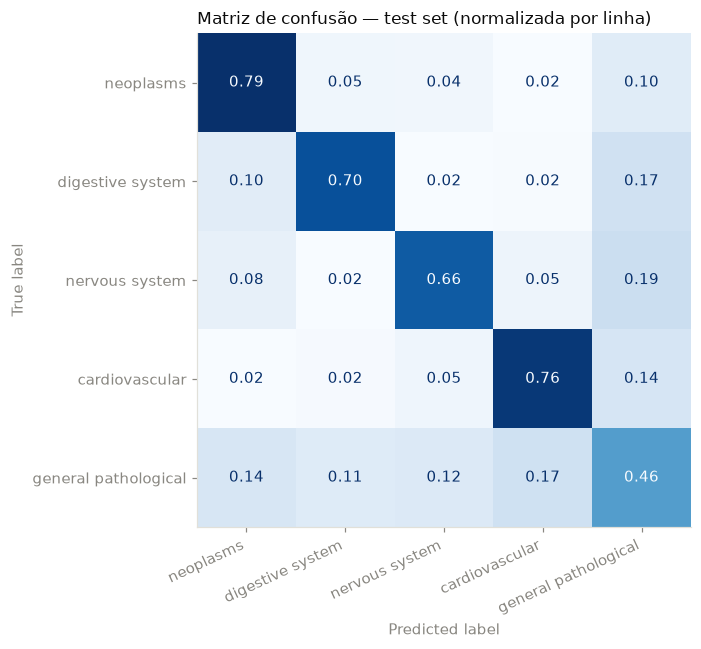

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=[n.replace(" diseases", "").replace(" conditions", "")
                    for n in class_names],
    normalize="true", values_format=".2f", cmap="Blues", colorbar=False, ax=ax,
)
ax.set_title("Matriz de confusão — test set (normalizada por linha)",
             loc="left", fontsize=11)
ax.grid(False)
plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
plt.tight_layout()
plt.show()

### Erros de alta confiança

Os erros em que o modelo depositou maior probabilidade são os mais informativos para diagnóstico: apontam pontos cegos reais do modelo ou fragilidades do gabarito.

In [7]:
proba = best_model.predict_proba(X_test)
conf = proba.max(axis=1)

errors = pd.DataFrame({
    "texto": X_test.str.slice(0, 140),
    "real": pd.Series(y_test).map(label_map).values,
    "previsto": pd.Series(y_pred).map(label_map).values,
    "confiança": conf.round(3),
})
errors = errors[errors["real"] != errors["previsto"]]
print(f"Erros no test: {len(errors):,} de {len(test):,} ({len(errors)/len(test):.1%})\n")
errors.sort_values("confiança", ascending=False).head(8)

Erros no test: 1,019 de 2,888 (35.3%)



,texto,real,previsto,confiança
1443,Inheritance of proliferative breast disease in...,general pathological conditions,neoplasms,0.983
1573,When is polypectomy sufficient treatment for c...,digestive system diseases,neoplasms,0.980
2711,Gynecologic cancer in patients with subacute c...,nervous system diseases,neoplasms,0.977
2425,Radiotherapy. The mainstay in the treatment of...,general pathological conditions,neoplasms,0.976
1924,The internist in the management of head and ne...,general pathological conditions,neoplasms,0.975
2249,Tumor factors predicting for prognosis in meta...,general pathological conditions,neoplasms,0.975
700,Prognostic value of immunocytologic detection ...,general pathological conditions,neoplasms,0.975
2628,Detection of human papillomavirus-genomic DNA ...,general pathological conditions,neoplasms,0.969


## 4. Artefatos

Pipeline completo (vetorizador + classificador) serializado como artefato único, acompanhado de `metrics.json` com a proveniência (hiperparâmetros, métricas, versões, semente). Artefatos não são versionados no git — sua geração é responsabilidade do pipeline de treino (DAG do Airflow, Etapa 2); estes servem de contrato para `src/train.py` e para a API.

In [8]:
import joblib
import sklearn

MODELS = Path("../models")
MODELS.mkdir(exist_ok=True)

joblib.dump(best_model, MODELS / "model.joblib")

metrics = {
    "model": "tfidf_logreg",
    "best_params": {k: str(v) for k, v in search.best_params_.items()},
    "f1_macro_cv": round(search.best_score_, 4),
    "f1_macro_test": round(f1_test, 4),
    "n_train": len(train),
    "n_test": len(test),
    "sklearn_version": sklearn.__version__,
    "random_state": RANDOM_STATE,
}
with open(MODELS / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

size_mb = (MODELS / "model.joblib").stat().st_size / 1e6
print(f"model.joblib salvo ({size_mb:.1f} MB)")
print(json.dumps(metrics, indent=2))

model.joblib salvo (7.1 MB)
{
  "model": "tfidf_logreg",
  "best_params": {
    "clf__C": "2.0",
    "vec__min_df": "2",
    "vec__ngram_range": "(1, 2)"
  },
  "f1_macro_cv": 0.7277,
  "f1_macro_test": 0.6504,
  "n_train": 8457,
  "n_test": 2888,
  "sklearn_version": "1.9.0",
  "random_state": 42
}


## 5. Síntese da fase de modelagem

1. **Comparação de modelos:** LogReg 0.717 > LinearSVC 0.699 > RandomForest 0.688 ≈ ComplementNB 0.687. Modelos lineares dominam o regime esparso; a LogReg alia o melhor F1 a probabilidades nativas e baixa latência.
2. **Otimização:** melhor configuração `C=2.0, min_df=2, ngram_range=(1,2)` → **CV 0.728 ± 0.004** (+0.011 sobre a referência). Bigramas e vocabulário ampliado só rendem com o C reajustado — validando o grid conjunto.
3. **Resultado final: F1 macro = 0.650 no test** (accuracy 0.647). A diferença para o CV (−0.078) é atribuível aos fatores antecipados: ambiguidade multi-label do gabarito do test, conteúdo novo após a limpeza e viés de seleção do grid — magnitude compatível com o teto documentado na EDA, sem evidência de overfitting metodológico.
4. **Análise de erros:** `general pathological conditions` concentra as perdas (recall 0.458), com vazamento para as classes específicas — hipótese da EDA confirmada. Os erros de maior confiança são majoritariamente textos oncológicos rotulados como `general` e preditos como `neoplasms` (confiança > 0.97): predições clinicamente defensáveis penalizadas pelo gabarito single-label.
5. **Configuração final:** TF-IDF `(stop_words=english, min_df=2, ngram_range=(1,2))` + LogReg `(C=2.0, class_weight=balanced)`; artefato de 7,1 MB; predição em lote dos 2.888 textos em ~0.1s.

**Handoff para produção:** `src/train.py` reproduz limpeza + configuração vencedora + `metrics.json`; a DAG do Airflow orquestra o treino (Etapa 2); a API serve `models/model.joblib` com probabilidades (Etapa 1); a otimização ONNX parte deste pipeline (Etapa 4).